In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# 1. Read raw CSV dataset from Volume
raw_csv_path = "/Volumes/workspace/default/my_data_volume/Superstore_dataset/Sample - Superstore.csv"
df_raw = spark.read.csv(raw_csv_path, header=True, inferSchema=True)

# 2. Sanitize column names: Replace spaces and hyphens with underscores
df_sanitized = df_raw
for column_name in df_raw.columns:
    clean_name = column_name.replace(" ", "_").replace("-", "_")
    df_sanitized = df_sanitized.withColumnRenamed(column_name, clean_name)

# 3. Hard-Drop PCI data (CVV / Security Codes)
pci_columns_to_drop = ["cvv", "CVV", "card_security_code", "security_code"]
existing_drop_cols = [c for c in pci_columns_to_drop if c in df_sanitized.columns]

df_bronze = df_sanitized.drop(*existing_drop_cols)

# 4. Save to Unity Catalog Volume as Delta Table
bronze_path = "/Volumes/workspace/default/my_data_volume/delta/bronze_retail_lakehouse"
df_bronze.write.format("delta").mode("overwrite").save(bronze_path)

print("Bronze Layer successfully created in Unity Catalog Volume with sanitized column names!")

Bronze Layer successfully created in Unity Catalog Volume with sanitized column names!


In [0]:
from pyspark.sql.functions import col, sha2, concat, lit, right

# 1. Load Bronze Delta Table from Volume
bronze_path = "/Volumes/workspace/default/my_data_volume/delta/bronze_retail_lakehouse"
df_bronze = spark.read.format("delta").load(bronze_path)

# 2. Tokenize and Mask Direct Identifiers (PII Protection)
df_silver = df_bronze

# SHA-256 Tokenization for Customer Name
if "Customer_Name" in df_silver.columns:
    df_silver = df_silver.withColumn("Customer_Token", sha2(col("Customer_Name"), 256)).drop("Customer_Name")

# SHA-256 Tokenization for Email (if present)
if "Email" in df_silver.columns:
    df_silver = df_silver.withColumn("Email_Token", sha2(col("Email"), 256)).drop("Email")

# Mask Credit Card retaining only last 4 digits (if present)
if "Credit_Card" in df_silver.columns:
    df_silver = df_silver.withColumn(
        "Credit_Card_Masked", 
        concat(lit("XXXX-XXXX-XXXX-"), right(col("Credit_Card"), 4))
    ).drop("Credit_Card")

# Backup tokenization for Customer_ID if Customer_Name is absent
if "Customer_ID" in df_silver.columns and "Customer_Token" not in df_silver.columns:
    df_silver = df_silver.withColumn("Customer_Token", sha2(col("Customer_ID"), 256))

# 3. Save to Silver Delta Table in Unity Catalog Volume
silver_path = "/Volumes/workspace/default/my_data_volume/delta/silver_retail_lakehouse"
df_silver.write.format("delta").mode("overwrite").save(silver_path)

print("Silver Layer successfully created with PII Tokenization & Masking!")
display(df_silver.limit(5))

Silver Layer successfully created with PII Tokenization & Masking!


Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Customer_Token
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0,41.9136,81f0ac57bc6708b59ef40d3a094049df2564aeebb2a60988af9067ee8451bebf
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.94,3,0,219.582,81f0ac57bc6708b59ef40d3a094049df2564aeebb2a60988af9067ee8451bebf
3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.62,2,0,6.8714,12baa372aa2b34f88fe8cde5e986730d85feb52498a5e601fe276ee917aab4ca
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.031,79412eca913e6f34aa530cc151cb8d4ed79e6c64942cfb9d6aa86292a8890a4a
5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164,79412eca913e6f34aa530cc151cb8d4ed79e6c64942cfb9d6aa86292a8890a4a


In [0]:
from pyspark.sql.functions import col, when, floor, datediff, current_date, expr, coalesce, lit

# 1. Load Silver Delta Table from Volume
silver_path = "/Volumes/workspace/default/my_data_volume/delta/silver_retail_lakehouse"
df_silver = spark.read.format("delta").load(silver_path)

# 2. Identify sales column and safely convert string values to numeric DOUBLE using SQL expr
sales_col = "Sales" if "Sales" in df_silver.columns else "amount"

df_silver_clean = df_silver.withColumn(
    sales_col, 
    coalesce(expr(f"try_cast(`{sales_col}` as double)"), lit(0.0))
)

# 3. Feature Engineering: Create Spend Categories
df_gold = df_silver_clean.withColumn(
    "Spend_Category",
    when(col(sales_col) < 1000, "Low (<1000)")
    .when((col(sales_col) >= 1000) & (col(sales_col) <= 5000), "Medium (1000-5000)")
    .otherwise("High (>5000)")
)

# 4. Feature Engineering: Convert DOB into Age Bands (if DOB exists)
dob_col = None
for c in ["DOB", "dob", "Birth_Date", "birth_date"]:
    if c in df_gold.columns:
        dob_col = c
        break

if dob_col:
    df_gold = df_gold.withColumn("Age", floor(datediff(current_date(), col(dob_col)) / 365.25)) \
        .withColumn("Age_Band", 
            when(col("Age") < 25, "Under 25")
            .when((col("Age") >= 25) & (col("Age") <= 34), "25-34")
            .when((col("Age") >= 35) & (col("Age") <= 50), "35-50")
            .otherwise("50+")
        ).drop(dob_col, "Age")

# 5. Save to Gold Delta Table in Unity Catalog Volume
gold_path = "/Volumes/workspace/default/my_data_volume/delta/gold_retail_lakehouse"
df_gold.write.format("delta").mode("overwrite").save(gold_path)

print("Gold Layer successfully created with Spend Categories and Feature Engineering!")
display(df_gold.select(sales_col, "Spend_Category", "Customer_Token").limit(5))

Gold Layer successfully created with Spend Categories and Feature Engineering!


Sales,Spend_Category,Customer_Token
261.96,Low (<1000),81f0ac57bc6708b59ef40d3a094049df2564aeebb2a60988af9067ee8451bebf
731.94,Low (<1000),81f0ac57bc6708b59ef40d3a094049df2564aeebb2a60988af9067ee8451bebf
14.62,Low (<1000),12baa372aa2b34f88fe8cde5e986730d85feb52498a5e601fe276ee917aab4ca
957.5775,Low (<1000),79412eca913e6f34aa530cc151cb8d4ed79e6c64942cfb9d6aa86292a8890a4a
22.368,Low (<1000),79412eca913e6f34aa530cc151cb8d4ed79e6c64942cfb9d6aa86292a8890a4a


/home/spark-e802b983-efe2-445e-96bc-65/.ipykernel/86/command-5383490941925650-2410340937:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cust_spend_pd, x=cust_col, y='Total_Sales', ax=ax1, palette='Blues_r')


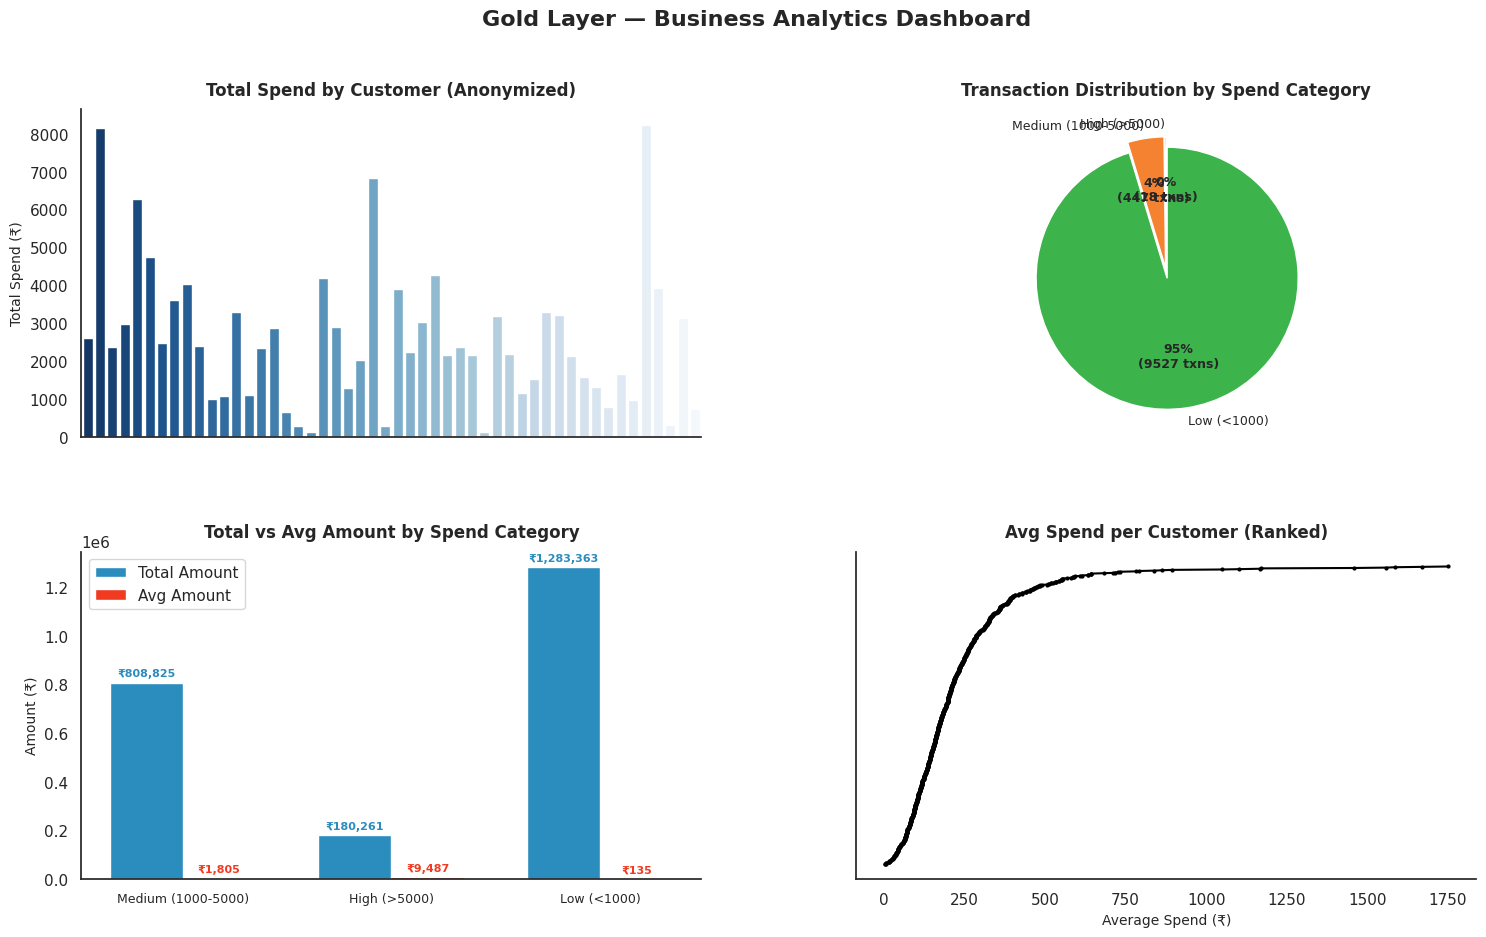

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import sum as _sum, avg as _avg, count as _count, col

# 1. Load Gold Delta Table from Volume
gold_path = "/Volumes/workspace/default/my_data_volume/delta/gold_retail_lakehouse"
df_gold = spark.read.format("delta").load(gold_path)

# 2. Determine Customer Token / ID column
cust_col = "Customer_Token" if "Customer_Token" in df_gold.columns else "Customer_ID"
sales_col = "Sales" if "Sales" in df_gold.columns else "amount"

# 3. Compute Aggregations in PySpark for efficient plotting
df_cust_spend_pd = df_gold.groupby(cust_col).agg(_sum(sales_col).alias("Total_Sales")).limit(50).toPandas()

df_cat_dist_pd = df_gold.groupby("Spend_Category").agg(_count("*").alias("Txn_Count")).toPandas()

df_cat_metrics_pd = df_gold.groupby("Spend_Category") \
    .agg(_sum(sales_col).alias("Total_Amount"), _avg(sales_col).alias("Avg_Amount")) \
    .toPandas()

df_cust_avg_pd = df_gold.groupby(cust_col) \
    .agg(_avg(sales_col).alias("Avg_Spend")) \
    .sort("Avg_Spend") \
    .toPandas()

# 4. Render Dashboard (2x2 Grid)
sns.set_theme(style="white")
fig = plt.figure(figsize=(18, 10), dpi=100)
fig.suptitle("Gold Layer — Business Analytics Dashboard", fontsize=16, fontweight='bold', y=0.98)

gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# --- CHART 1: Total Spend by Customer ---
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(data=df_cust_spend_pd, x=cust_col, y='Total_Sales', ax=ax1, palette='Blues_r')
ax1.set_title("Total Spend by Customer (Anonymized)", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("")
ax1.set_ylabel("Total Spend (₹)", fontsize=10)
ax1.set_xticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- CHART 2: Transaction Distribution by Spend Category (Pie) ---
ax2 = fig.add_subplot(gs[0, 1])
category_order = ['High (>5000)', 'Medium (1000-5000)', 'Low (<1000)']
df_cat_dist_pd['Spend_Category'] = pd.Categorical(df_cat_dist_pd['Spend_Category'], categories=category_order, ordered=True)
df_cat_dist_pd = df_cat_dist_pd.sort_values('Spend_Category')

colors = ['#e6194B', '#f58231', '#3cb44b']
total_txns = df_cat_dist_pd['Txn_Count'].sum()

wedges, texts, autotexts = ax2.pie(
    df_cat_dist_pd['Txn_Count'], 
    labels=df_cat_dist_pd['Spend_Category'], 
    autopct=lambda p: f'{p:.0f}%\n({int(p*total_txns/100)} txns)',
    startangle=90, 
    colors=colors, 
    explode=(0.04, 0.04, 0.04),
    textprops=dict(fontsize=9)
)
for autotext in autotexts:
    autotext.set_weight('bold')
ax2.set_title("Transaction Distribution by Spend Category", fontsize=12, fontweight='bold', pad=10)

# --- CHART 3: Total vs Avg Amount by Spend Category ---
ax3 = fig.add_subplot(gs[1, 0])
x = np.arange(len(df_cat_metrics_pd))
width = 0.35

rects1 = ax3.bar(x - width/2, df_cat_metrics_pd['Total_Amount'], width, label='Total Amount', color='#2b8cbe')
rects2 = ax3.bar(x + width/2, df_cat_metrics_pd['Avg_Amount'], width, label='Avg Amount', color='#f03b20')

ax3.set_title("Total vs Avg Amount by Spend Category", fontsize=12, fontweight='bold', pad=10)
ax3.set_xticks(x)
ax3.set_xticklabels(df_cat_metrics_pd['Spend_Category'], fontsize=9)
ax3.set_ylabel("Amount (₹)", fontsize=10)
ax3.legend(loc='upper left')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Add value annotations
for bar in rects1:
    h = bar.get_height()
    ax3.annotate(f'₹{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2b8cbe')
for bar in rects2:
    h = bar.get_height()
    ax3.annotate(f'₹{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#f03b20')

# --- CHART 4: Avg Spend per Customer (Ranked) ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df_cust_avg_pd['Avg_Spend'], df_cust_avg_pd.index, marker='o', color='black', linewidth=1.5, markersize=2)
ax4.set_title("Avg Spend per Customer (Ranked)", fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel("Average Spend (₹)", fontsize=10)
ax4.set_yticks([])
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.show()